# Visualize Data Augmentation Methods
This notebook visualizes the data augmentation methods used in `preprocess_clean_augment.py`.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import albumentations as A
import json
import os
import random

# Load original dataset to get samples
dataset_path = 'zalo_dataset'
source_images = os.path.join(dataset_path, 'traffic_train/traffic_train/images')
json_file = os.path.join(dataset_path, 'traffic_train/traffic_train/train_traffic_sign_dataset.json')

with open(json_file, 'r') as f:
    coco_data = json.load(f)

annotations = coco_data['annotations']
images = {img['id']: img for img in coco_data['images']}
categories = {cat['id']: cat['name'] for cat in coco_data['categories']}

image_annotations = {}
for ann in annotations:
    img_id = ann['image_id']
    if img_id not in image_annotations:
        image_annotations[img_id] = []
    image_annotations[img_id].append(ann)


In [ ]:
def draw_boxes(ax, image, bboxes, category_ids):
    ax.imshow(image)
    for bbox, cat_id in zip(bboxes, category_ids):
        x, y, w, h = map(int, bbox)
        # Handle potential string vs int keys depending on JSON
        label = categories.get(int(cat_id), str(cat_id))
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, label, color='white', fontsize=10, backgroundcolor='red')
    ax.axis('off')

def visualize_augmentation(transform, name, sample_img_ids):
    print(f"\n{'='*50}\nMethod: {name}\n{'='*50}")
    for img_id in sample_img_ids:
        img_info = images[img_id]
        img_path = os.path.join(source_images, img_info['file_name'])
        image = cv2.imread(img_path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        img_anns = image_annotations.get(img_id, [])
        bboxes = [ann['bbox'] for ann in img_anns]
        category_ids = [ann['category_id'] for ann in img_anns]

        # Handle images with empty boxes or invalid boxes for albumentations
        # filtering small boxes just in case
        valid_bboxes = []
        valid_cats = []
        for b, c in zip(bboxes, category_ids):
            if b[2] > 0 and b[3] > 0 and b[2]*b[3] >= 40:
                valid_bboxes.append(b)
                valid_cats.append(c)

        if not valid_bboxes:
            continue

        try:
            transformed = transform(image=image, bboxes=valid_bboxes, category_ids=valid_cats)
        except Exception as e:
            print(f"Error applying transform on image {img_id}: {e}")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f"Image ID: {img_id}", fontsize=14)

        axes[0].set_title("Original")
        draw_boxes(axes[0], image, valid_bboxes, valid_cats)

        axes[1].set_title(f"Augmented ({name})")
        draw_boxes(axes[1], transformed['image'], transformed['bboxes'], transformed['category_ids'])

        plt.show()


In [3]:
# Select 3 random images that have at least one annotation
random.seed(42)
valid_img_ids = [img_id for img_id, anns in image_annotations.items() if len(anns) > 0]
sample_img_ids = random.sample(valid_img_ids, 3)

print("Sample images to visualize:", sample_img_ids)


Sample images to visualize: [4121, 693, 6373]


/Users/duongthanhduy/miniconda3-new/envs/traffic_signs/lib/python3.12/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()



Method: Random Brightness & Contrast


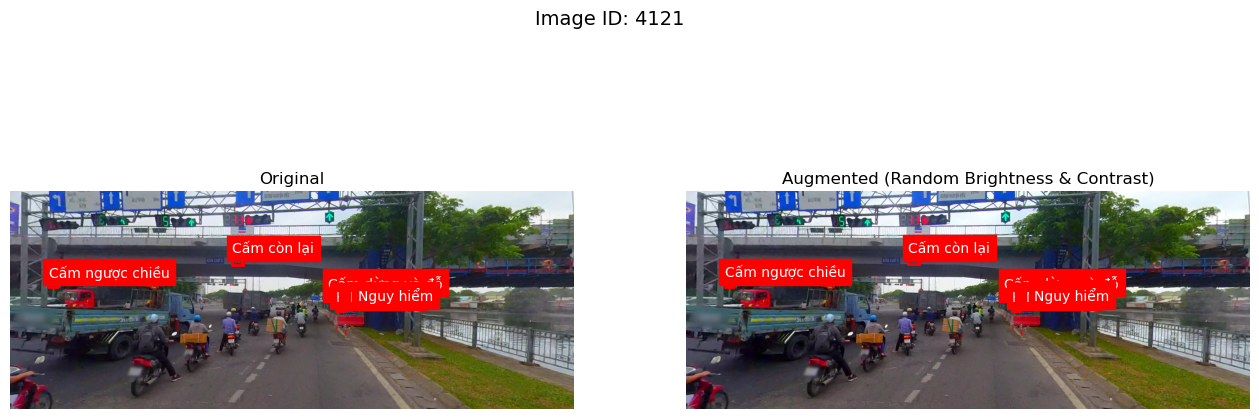

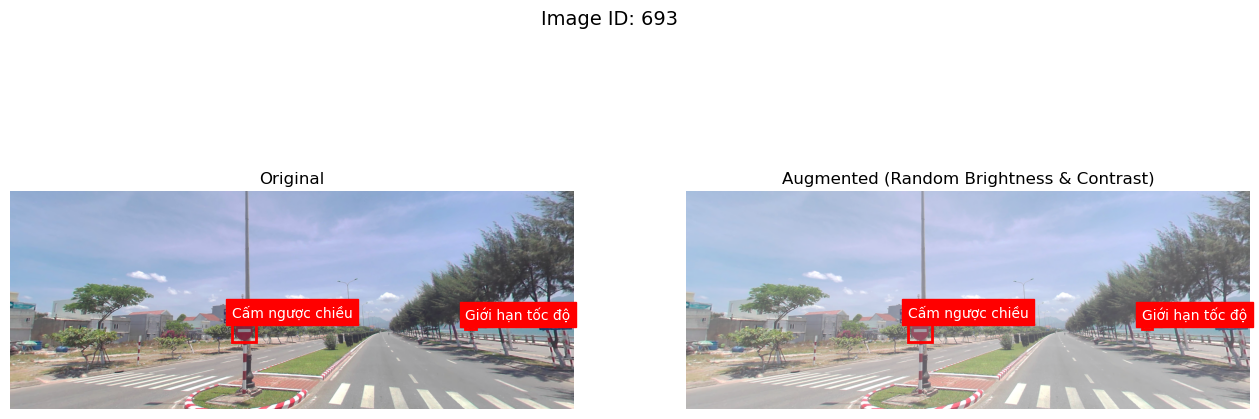

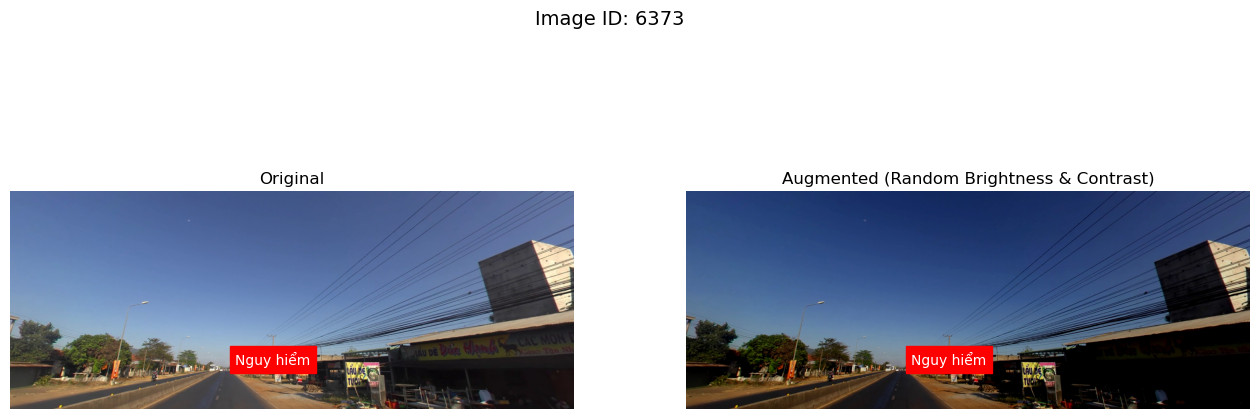


Method: Horizontal Flip


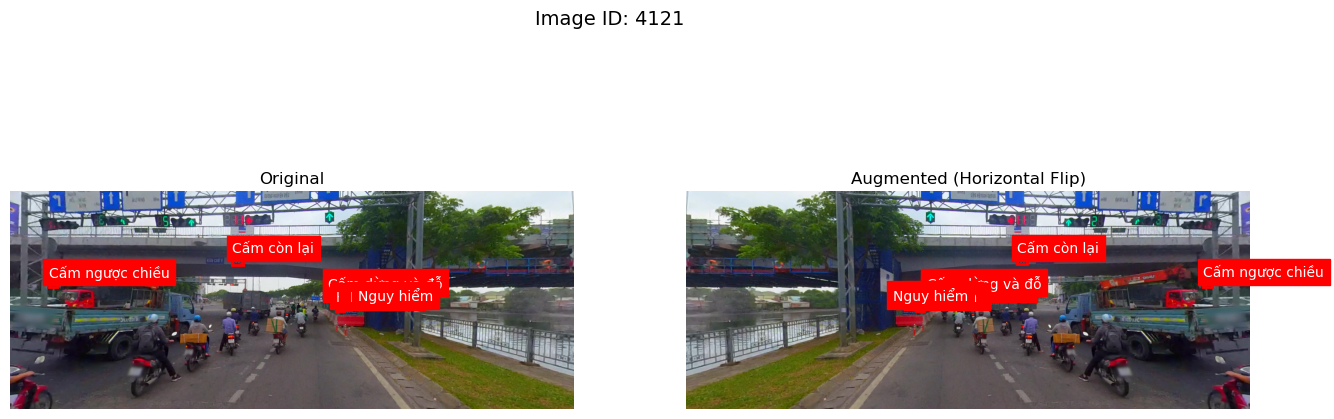

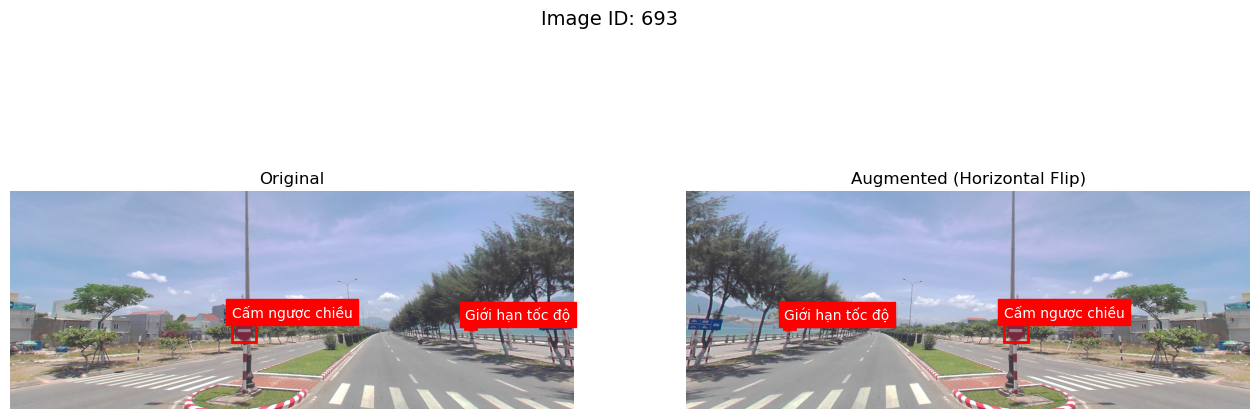

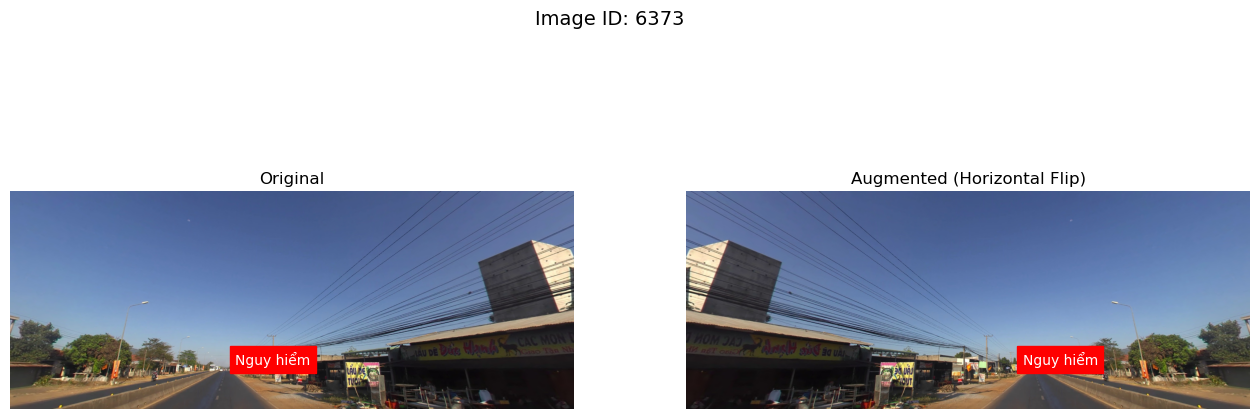


Method: Gaussian Blur


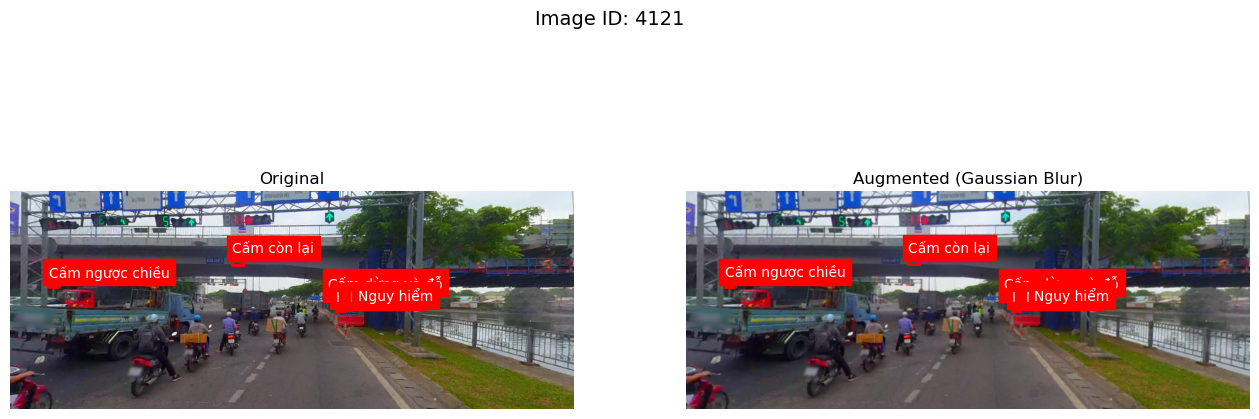

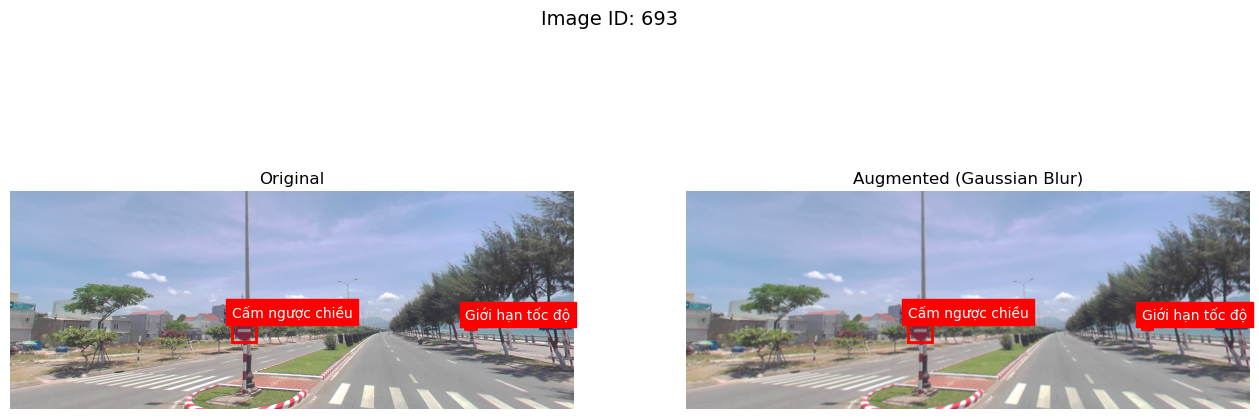

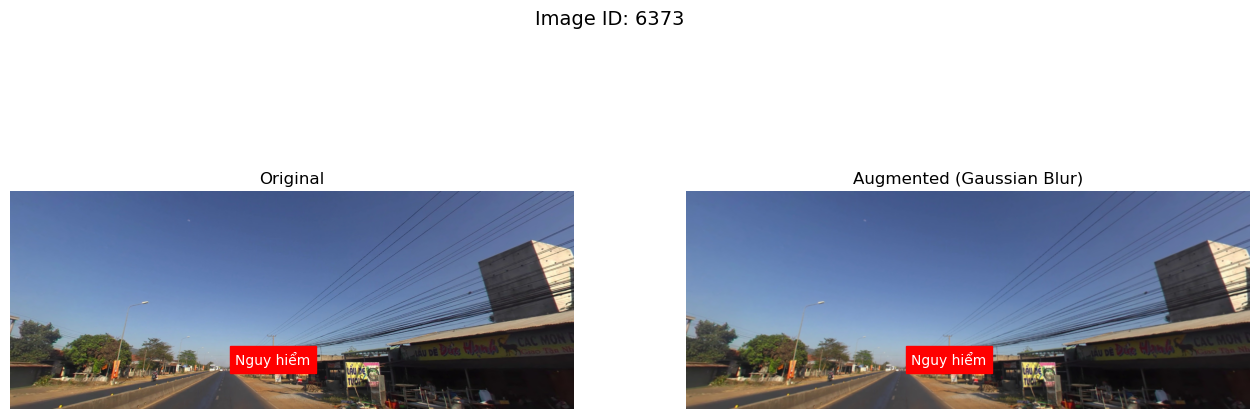


Method: Motion Blur


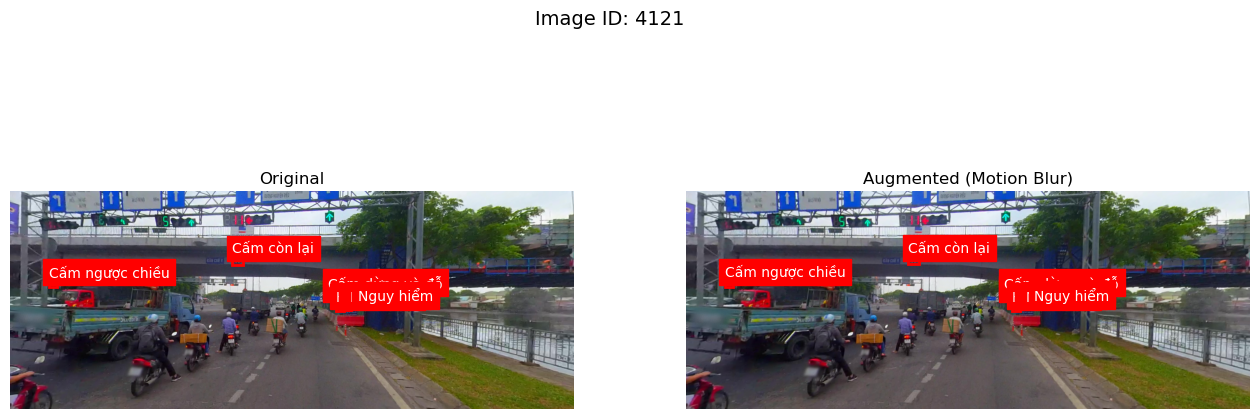

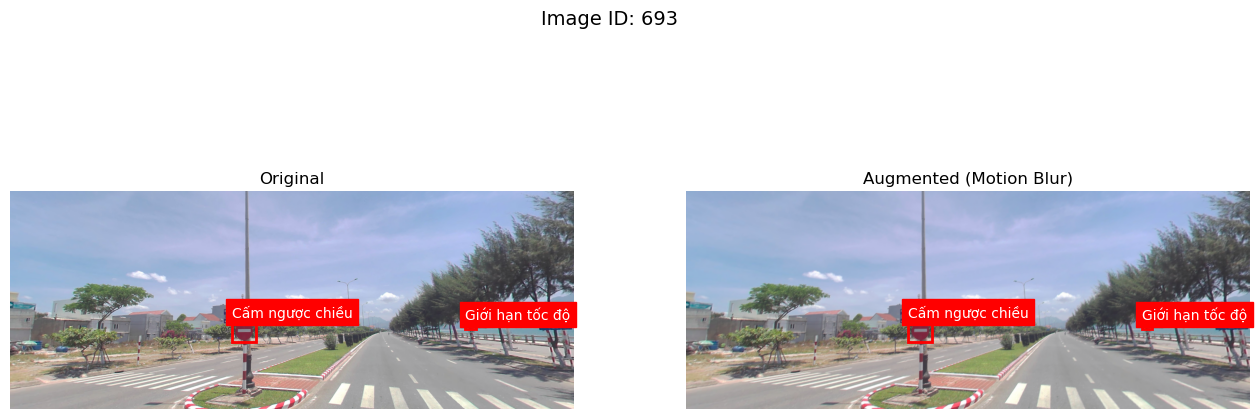

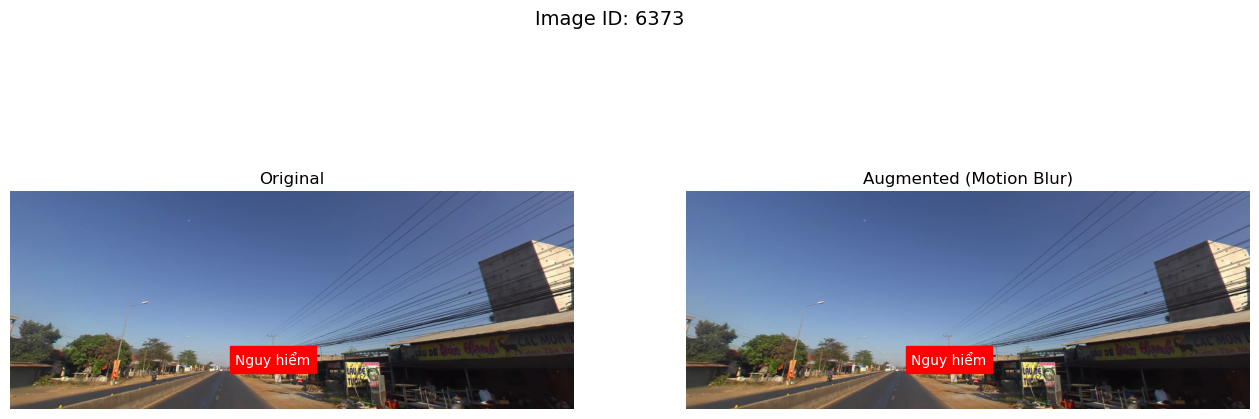


Method: Random Sized BBox Safe Crop


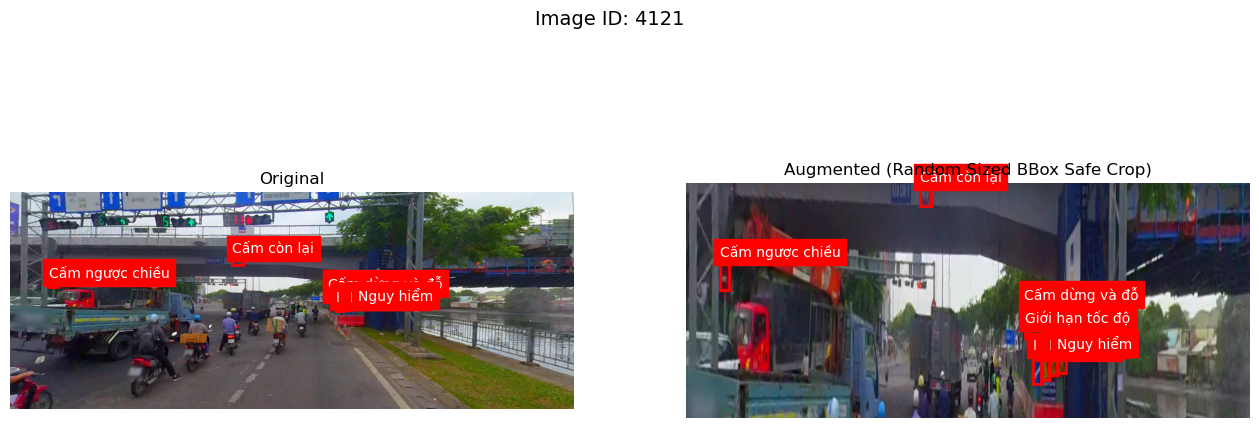

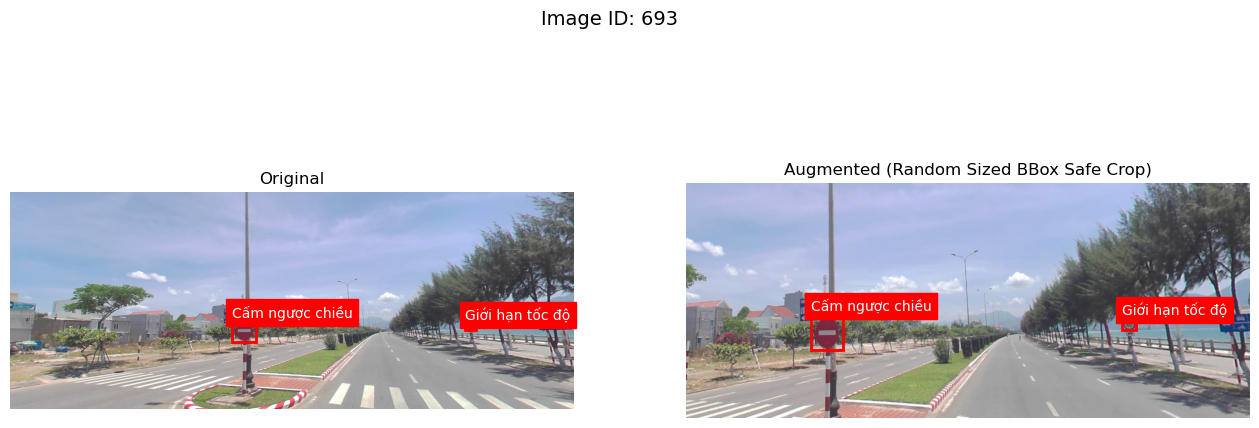

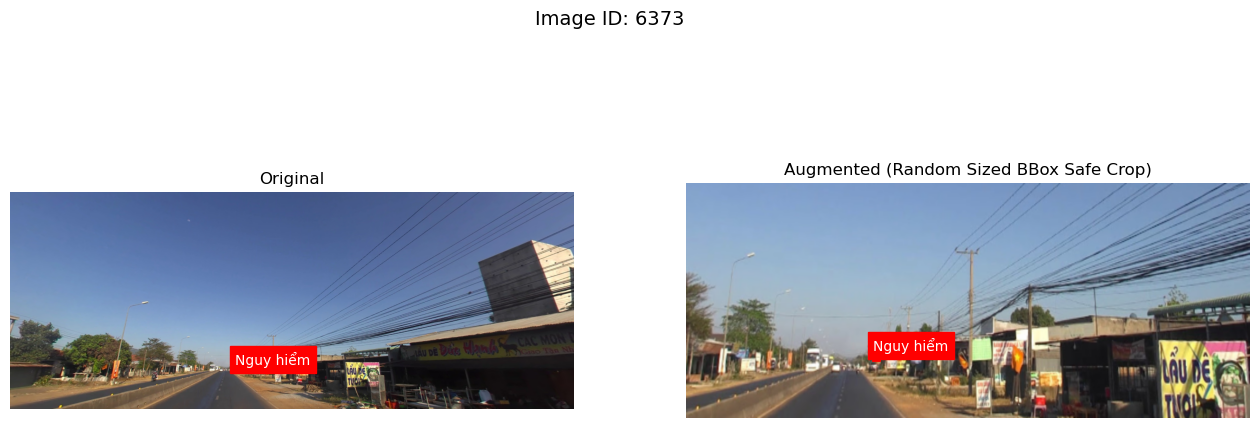

In [4]:
bbox_params = A.BboxParams(format='coco', label_fields=['category_ids'], min_area=40, min_visibility=0.3)

# 1. Random Brightness Contrast
transform_1 = A.Compose([A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0)], bbox_params=bbox_params)
visualize_augmentation(transform_1, "Random Brightness & Contrast", sample_img_ids)

# 2. Horizontal Flip
transform_2 = A.Compose([A.HorizontalFlip(p=1.0)], bbox_params=bbox_params)
visualize_augmentation(transform_2, "Horizontal Flip", sample_img_ids)

# 3. Gaussian Blur
transform_3 = A.Compose([A.GaussianBlur(blur_limit=(3, 7), p=1.0)], bbox_params=bbox_params)
visualize_augmentation(transform_3, "Gaussian Blur", sample_img_ids)

# 4. Motion Blur
transform_4 = A.Compose([A.MotionBlur(blur_limit=(3, 7), p=1.0)], bbox_params=bbox_params)
visualize_augmentation(transform_4, "Motion Blur", sample_img_ids)

# 5. Random Sized BBox Safe Crop
# Note: Safe crop needs size smaller than the image, defaulting to (300, 300) might be safer for visualization if images are small
transform_5 = A.Compose([A.RandomSizedBBoxSafeCrop(height=500, width=1200, erosion_rate=0.2, p=1.0)], bbox_params=bbox_params)
visualize_augmentation(transform_5, "Random Sized BBox Safe Crop", sample_img_ids)
